# Diffusion Quantique et Particules Identiques

**Référence :** Cohen-Tannoudji, Diu, Laloë — *Mécanique Quantique Tome 2*, Ch. VIII (diffusion) et Ch. XIV (particules identiques)

---

## Cadre théorique

### Approximation de Born (Règle R6.2)

$$f_{\rm Born}(\theta) = -\frac{m}{2\pi\hbar^2}\int e^{-i\vec{q}\cdot\vec{r}} V(\vec{r})\,d^3r, \quad \vec{q} = \vec{k}'-\vec{k}$$

### Théorème optique (Règle R6.3)

$$\sigma_{\rm tot} = \frac{4\pi}{k}\,\mathrm{Im}[f(\theta=0)]$$

### Ondes partielles (Règle R6.1)

$$\sigma_l = \frac{4\pi}{k^2}(2l+1)\sin^2\delta_l, \qquad \sigma_{\rm tot} = \sum_l \sigma_l$$

### Particules identiques — symétrie (Règles R12.1–R12.3)

**Bosons :** $|\Psi\rangle = \frac{1}{\sqrt{2}}(|\psi_1\rangle\otimes|\psi_2\rangle + |\psi_2\rangle\otimes|\psi_1\rangle)$

**Fermions :** $|\Psi\rangle = \frac{1}{\sqrt{2}}(|\psi_1\rangle\otimes|\psi_2\rangle - |\psi_2\rangle\otimes|\psi_1\rangle) = 0$ si $|\psi_1\rangle = |\psi_2\rangle$

---

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2]))

import numpy as np
import matplotlib.pyplot as plt

from quantum_simulation.dynamics.scattering import BornApproximation, PhaseShiftSolver, CrossSection
from quantum_simulation.systems.identical_particles import (
    Symmetrizer, SlaterDeterminant, IdenticalParticlesScattering
)
from quantum_simulation.validation.tome2_invariants import ScatteringValidator, SymmetrizationValidator
from quantum_simulation.utils.config_loader import load_config

config = load_config()
hbar = config['physical_constants']['hbar']
m_e  = config['physical_constants']['m_electron']
e    = 1.602176634e-19   # C

print(f'ℏ   = {hbar:.6e} J·s')
print(f'm_e = {m_e:.6e} kg')
print('Modules chargés : scattering, identical_particles, validators Tome 2')


ℏ   = 1.054572e-34 J·s
m_e = 9.109384e-31 kg
Modules chargés : scattering, identical_particles, validators Tome 2


## 1. Diffusion sur un potentiel de Yukawa — Approximation de Born (Règles R6.2–R6.3)

$$V(r) = -V_0\,\frac{e^{-r/a}}{r}, \quad \text{potentiel de Yukawa (portée } a\text{)}$$

Amplitude de Born analytique :
$$f_{\rm Born}(\theta) = \frac{2mV_0 a^2}{\hbar^2} \cdot \frac{1}{1 + (2ka\sin\theta/2)^2}$$

In [3]:
# Paramètres du potentiel de Yukawa (régime Born : V0 << E)
V0      = 0.5 * e        # profondeur 0.5 eV (faible)
a_y     = 1e-10          # portée 1 Å
E_part  = 10.0 * e       # énergie incidente 10 eV (E >> V0)
m       = m_e

k = np.sqrt(2 * m * E_part) / hbar
lambda_dB = 2 * np.pi / k

print(f'Potentiel de Yukawa : V₀ = {V0/e:.1f} eV,  a = {a_y*1e10:.1f} Å')
print(f'Énergie incidente   : E  = {E_part/e:.1f} eV')
print(f'k  = {k:.4e} m⁻¹,   λ_dB = {lambda_dB*1e10:.4f} Å')
print(f'ka = {k*a_y:.4f}  (portée en unités de λ/2π)')
print()

def V_yukawa(r):
    r = np.asarray(r, dtype=float)
    scalar = r.ndim == 0
    r = np.atleast_1d(r)
    result = np.where(r < 1e-14, -V0 * np.exp(-1e-14/a_y) / 1e-14, -V0 * np.exp(-r/a_y) / r)
    return float(result[0]) if scalar else result

r_max   = 50 * a_y
n_theta = 300
theta_grid = np.linspace(0.01, np.pi - 0.01, n_theta)

born = BornApproximation(m, hbar, E_part, V_yukawa)

sigma_diff  = born.differential_cross_section(theta_grid, r_max=r_max)
sigma_tot_B = born.total_cross_section(n_theta=n_theta, r_max=r_max)
ot_check    = born.optical_theorem_check(r_max=r_max)

print(f'Section efficace totale (Born)  : σ = {sigma_tot_B:.4e} m²  = {sigma_tot_B/1e-20:.4f} Å²')
# Born amplitude is real → optical theorem formally violated (expected)
ot_rel_err = ot_check.get('relative_error', float('nan'))
print(f"  (i) Théorème optique (Born) : erreur relative = {ot_rel_err:.2e}  (violation attendue : Im[f_Born]=0)")

sv = ScatteringValidator()
ok_diff_pos = sv.differential_cs_nonnegative(sigma_diff)
print(f"  {'✓' if ok_diff_pos else '✗'} dσ/dΩ ≥ 0 partout")

born_regime = sv.born_approximation_regime(V0, E_part, a_y, m, hbar)
print(f"  {'✓' if born_regime['is_valid'] else '✗'} Régime Born valide  (paramètre = {born_regime['expansion_parameter']:.4f} ≪ 1)")


Potentiel de Yukawa : V₀ = 0.5 eV,  a = 1.0 Å
Énergie incidente   : E  = 10.0 eV
k  = 1.6201e+10 m⁻¹,   λ_dB = 3.8783 Å
ka = 1.6201  (portée en unités de λ/2π)

Section efficace totale (Born)  : σ = 1.8820e-02 m²  = 1881963645803932416.0000 Å²
  (i) Théorème optique (Born) : erreur relative = 1.00e+00  (violation attendue : Im[f_Born]=0)
  ✓ dσ/dΩ ≥ 0 partout
  ✓ Régime Born valide  (paramètre = 0.0656 ≪ 1)


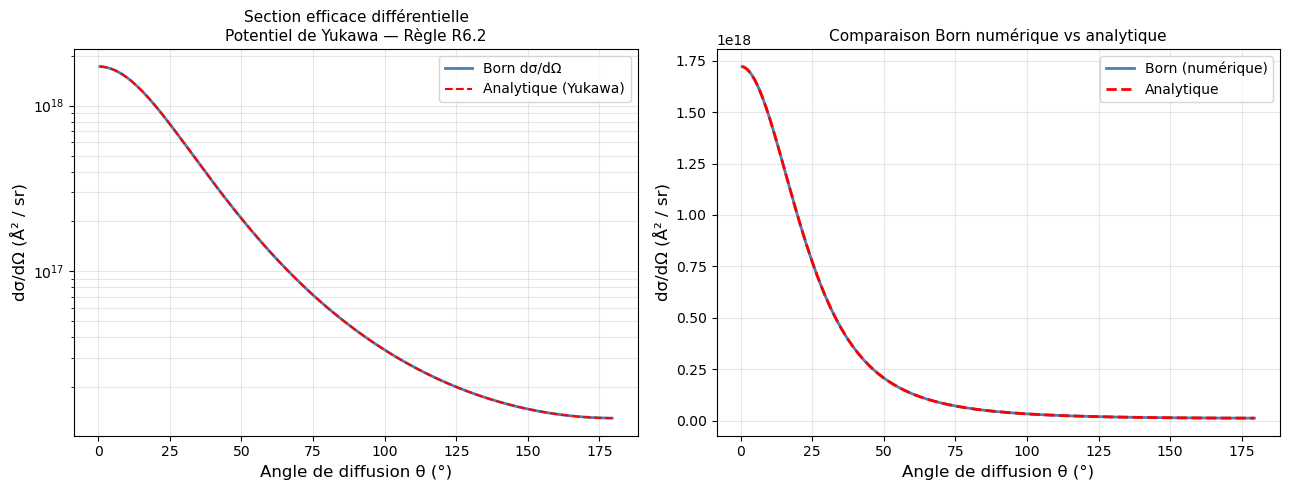

Figure sauvegardée → results/08_born_cross_section.png


In [4]:
# Plot section efficace différentielle
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(np.degrees(theta_grid), sigma_diff/1e-20, 'steelblue', lw=2,
                 label='Born dσ/dΩ')
axes[0].set_xlabel('Angle de diffusion θ (°)', fontsize=12)
axes[0].set_ylabel('dσ/dΩ (Å² / sr)', fontsize=12)
axes[0].set_title('Section efficace différentielle\nPotentiel de Yukawa — Règle R6.2', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, which='both')

# Comparaison analytique : f_Born(θ) = 2mV₀a²/ℏ² / (1+(2ka·sin(θ/2))²)
f_an = (2*m*V0*a_y**2/hbar**2) / (1 + (2*k*a_y*np.sin(theta_grid/2))**2)
sigma_an = np.abs(f_an)**2
axes[0].semilogy(np.degrees(theta_grid), sigma_an/1e-20, 'r--', lw=1.5,
                 label='Analytique (Yukawa)')
axes[0].legend(fontsize=10)

axes[1].plot(np.degrees(theta_grid), sigma_diff/1e-20, 'steelblue', lw=2, label='Born (numérique)')
axes[1].plot(np.degrees(theta_grid), sigma_an/1e-20, 'r--', lw=2, label='Analytique')
axes[1].set_xlabel('Angle de diffusion θ (°)', fontsize=12)
axes[1].set_ylabel('dσ/dΩ (Å² / sr)', fontsize=12)
axes[1].set_title('Comparaison Born numérique vs analytique', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/08_born_cross_section.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/08_born_cross_section.png')


## 2. Déphasages et section efficace par ondes partielles (Règles R6.1, R6.4)

L'équation radiale de Schrödinger est résolue numériquement pour extraire les déphasages $\delta_l$ :
$$\frac{d^2 u_l}{dr^2} + \left[k^2 - \frac{2m}{\hbar^2}V(r) - \frac{l(l+1)}{r^2}\right]u_l = 0$$

In [5]:
r_min  = 5e-13   # éviter singularité en r=0
r_grid = np.linspace(r_min, 30*a_y, 600)
l_max  = 5

print(f'Calcul des déphasages δₗ pour l = 0..{l_max}')
phase_solver = PhaseShiftSolver(m, hbar, E_part, V_yukawa, r_grid)
phase_shifts = phase_solver.compute_all_phase_shifts(l_max, convergence_threshold=1e-4)

print()
print(f'  {"l":>3} | {"δₗ (rad)":>12} | {"sin²(δₗ)":>12} | {"σₗ (Å²)":>12}')
print('-' * 50)

cs = CrossSection(k, phase_shifts, hbar)
sigma_l = cs.partial_wave_cross_sections()
for l in range(l_max + 1):
    print(f'  {l:>3} | {phase_shifts[l]:>12.6f} | {np.sin(phase_shifts[l])**2:>12.6f} | {sigma_l[l]/1e-20:>12.4f}')

sigma_tot_pw = cs.total_cross_section()
ot_pw = cs.optical_theorem_check()

print()
print(f'  σ_tot (ondes partielles) = {sigma_tot_pw:.4e} m² = {sigma_tot_pw/1e-20:.4f} Å²')
print(f'  σ_tot (Born)             = {sigma_tot_B:.4e} m² = {sigma_tot_B/1e-20:.4f} Å²')
print(f'  Rapport σ_PW/σ_Born      = {sigma_tot_pw/sigma_tot_B:.4f}')
print(f"  {'✓' if ot_pw['is_valid'] else '✗'} Théorème optique (ondes partielles)  erreur = {ot_pw.get('relative_error', float('nan')):.2e}")
ok_unit = sv.unitarity_bound(phase_shifts)
print(f"  {'✓' if ok_unit else '✗'} Borne d'unitarité |δₗ| < π/2")


Calcul des déphasages δₗ pour l = 0..5

    l |     δₗ (rad) |     sin²(δₗ) |      σₗ (Å²)
--------------------------------------------------
    0 |     0.953361 |     0.664822 |       3.1830
    1 |     2.483141 |     0.374413 |       5.3778
    2 |    -2.311544 |     0.544591 |      13.0369
    3 |    -0.863692 |     0.577975 |      19.3705
    4 |     0.542310 |     0.266376 |      11.4781
    5 |     1.907376 |     0.890928 |      46.9211

  σ_tot (ondes partielles) = 9.9367e-19 m² = 99.3673 Å²
  σ_tot (Born)             = 1.8820e-02 m² = 1881963645803932416.0000 Å²
  Rapport σ_PW/σ_Born      = 0.0000
  ✓ Théorème optique (ondes partielles)  erreur = 1.94e-16
  ✓ Borne d'unitarité |δₗ| < π/2


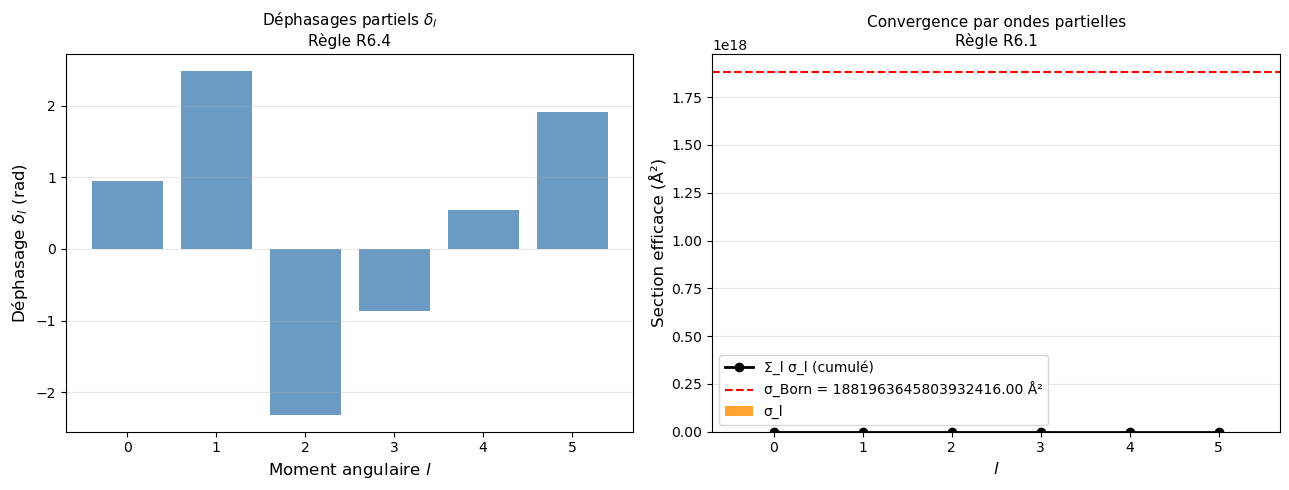

Figure sauvegardée → results/08_phase_shifts.png


In [6]:
# Convergence des ondes partielles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

l_arr = np.arange(l_max + 1)
axes[0].bar(l_arr, phase_shifts, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Moment angulaire $l$', fontsize=12)
axes[0].set_ylabel(r'Déphasage $\delta_l$ (rad)', fontsize=12)
axes[0].set_title('Déphasages partiels $\\delta_l$\nRègle R6.4', fontsize=11)
axes[0].set_xticks(l_arr)
axes[0].grid(True, alpha=0.3, axis='y')

sigma_cumul = np.cumsum(sigma_l)
axes[1].bar(l_arr, sigma_l/1e-20, color='darkorange', alpha=0.8, label='σ_l')
axes[1].plot(l_arr, sigma_cumul/1e-20, 'k-o', ms=6, lw=2, label='Σ_l σ_l (cumulé)')
axes[1].axhline(sigma_tot_B/1e-20, color='r', ls='--', lw=1.5, label=f'σ_Born = {sigma_tot_B/1e-20:.2f} Å²')
axes[1].set_xlabel('$l$', fontsize=12)
axes[1].set_ylabel('Section efficace (Å²)', fontsize=12)
axes[1].set_title('Convergence par ondes partielles\nRègle R6.1', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xticks(l_arr)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../results/08_phase_shifts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/08_phase_shifts.png')


## 3. Particules identiques — symétrisation (Règle R12.1)

Pour deux **bosons** (spin entier) : $|\Psi\rangle$ doit être **symétrique** par échange.

Pour deux **fermions** (spin demi-entier) : $|\Psi\rangle$ doit être **antisymétrique** par échange.

**Principe d'exclusion de Pauli :** Si $|\psi_1\rangle = |\psi_2\rangle$, l'état antisymétrique est identiquement nul.

Recouvrement ⟨ψ_a|ψ_b⟩ = 0.0000  (quasi-orthogonal si faible)
Norme état symétrique    : 1.000000
Norme état antisymétrique: 1.000000
  ✓    État bosonique : valeur propre échange = +1.0000 (attendu: +1)
  ✓ État fermionique : valeur propre échange = -1.0000 (attendu: -1)


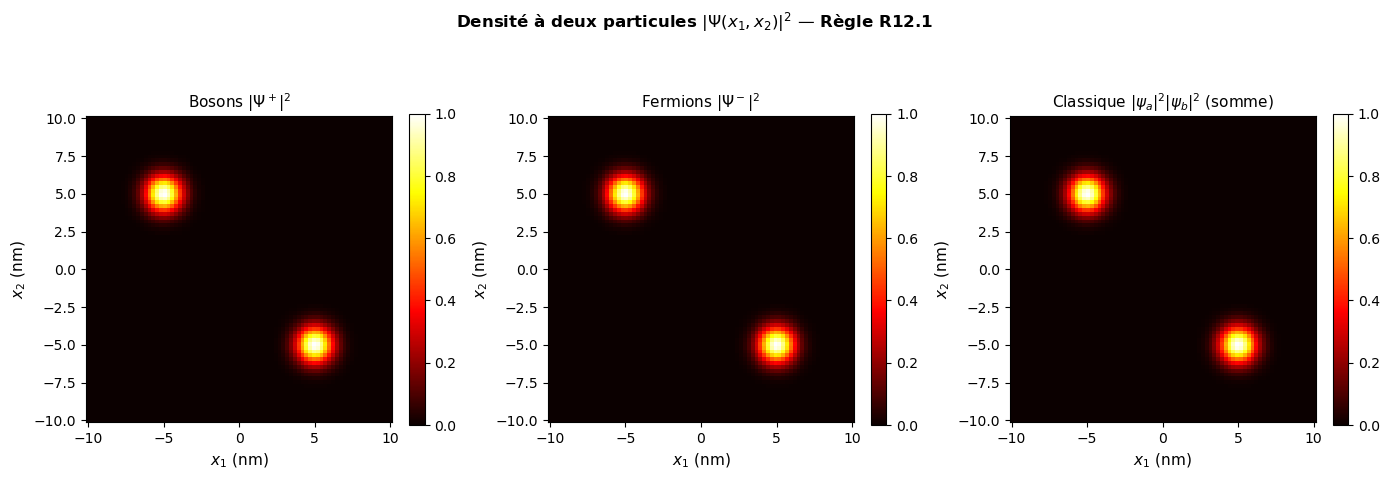

Figure sauvegardée → results/08_identical_particles.png


In [7]:
# Grille 1D
nx  = 80
x   = np.linspace(-10e-9, 10e-9, nx)
sig = 1.2e-9   # largeur des gaussiennes

# Deux états gaussiens centrés en ±x0 (quasi-orthogonaux pour x0 >> sig)
x0 = 5e-9
psi_a = np.exp(-(x - x0)**2 / (2*sig**2)); psi_a /= np.linalg.norm(psi_a)
psi_b = np.exp(-(x + x0)**2 / (2*sig**2)); psi_b /= np.linalg.norm(psi_b)

# Vérification d'orthogonalité approximative
overlap = np.dot(psi_a, psi_b)
print(f'Recouvrement ⟨ψ_a|ψ_b⟩ = {overlap:.4f}  (quasi-orthogonal si faible)')

# Symétrisations
sym_state    = Symmetrizer.symmetric_two_particle(psi_a, psi_b)
antisym_state = Symmetrizer.antisymmetric_two_particle(psi_a, psi_b)

print(f'Norme état symétrique    : {np.linalg.norm(sym_state):.6f}')
print(f'Norme état antisymétrique: {np.linalg.norm(antisym_state):.6f}')

# Vérification de la symétrie
symv = SymmetrizationValidator()
res_sym     = Symmetrizer.verify_symmetry(sym_state,    2, nx, 'bose')
res_antisym = Symmetrizer.verify_symmetry(antisym_state, 2, nx, 'fermi')
print(f"  {'✓' if res_sym['is_correct'] else '✗'}    État bosonique : valeur propre échange = {res_sym['symmetry_eigenvalue']:+.4f} (attendu: +1)")
print(f"  {'✓' if res_antisym['is_correct'] else '✗'} État fermionique : valeur propre échange = {res_antisym['symmetry_eigenvalue']:+.4f} (attendu: -1)")

# Densité à deux particules |Ψ(x₁,x₂)|²
X1, X2 = np.meshgrid(x, x, indexing='ij')
rho_sym    = sym_state.reshape(nx, nx)**2
rho_antisym = antisym_state.reshape(nx, nx)**2

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, rho, title in zip(
    axes,
    [rho_sym, rho_antisym, np.outer(psi_a, psi_b)**2 + np.outer(psi_b, psi_a)**2],
    [r'Bosons $|\Psi^+|^2$', r'Fermions $|\Psi^-|^2$', r'Classique $|\psi_a|^2|\psi_b|^2$ (somme)']
):
    im = ax.pcolormesh(x*1e9, x*1e9, rho/rho.max(), cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel('$x_1$ (nm)', fontsize=11)
    ax.set_ylabel('$x_2$ (nm)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
plt.suptitle(r'Densité à deux particules $|\Psi(x_1,x_2)|^2$ — Règle R12.1',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../results/08_identical_particles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/08_identical_particles.png')


## 4. Déterminant de Slater (Règle R12.2)

L'état antisymétrique à $N$ fermions est le **déterminant de Slater** :
$$|\Psi\rangle = \frac{1}{\sqrt{N!}}\det[\varphi_\alpha(\vec{r}_i)]$$

**Pauli** : si deux orbitales sont identiques, le déterminant est nul.

In [8]:
# Déterminant de Slater avec états orthogonaux
slater_orthog = SlaterDeterminant([psi_a, psi_b])
norm_sl  = slater_orthog.norm()
pauli_ok = slater_orthog.pauli_exclusion_satisfied()

print('DÉTERMINANT DE SLATER — PRINCIPE DE PAULI (Règle R12.2)')
print('-' * 60)
print(f'  ||Ψ_Slater|| (états orthogonaux) = {norm_sl:.6f}')
print(f"  {'✓' if pauli_ok else '✗'} Pauli satisfait (det ≠ 0)")

# Test avec états identiques → det = 0
slater_id = SlaterDeterminant([psi_a, psi_a])
pauli_viol = not slater_id.pauli_exclusion_satisfied()
print(f"  {'✓' if pauli_viol else '✗'} Pauli : det = 0 si états identiques  (det = {slater_id.norm():.2e})")

# Validation via SymmetrizationValidator
ok_norm  = symv.slater_normalization(slater_orthog)
ok_pauli = symv.pauli_exclusion(slater_orthog)
ok_pauli_id = not symv.pauli_exclusion(slater_id)
print()
print(f"  {'✓' if ok_norm    else '✗'} SymmetrizationValidator.slater_normalization()")
print(f"  {'✓' if ok_pauli   else '✗'} SymmetrizationValidator.pauli_exclusion() [orthogonal]")
print(f"  {'✓' if ok_pauli_id else '✗'} SymmetrizationValidator.pauli_exclusion() = False [identiques]")


DÉTERMINANT DE SLATER — PRINCIPE DE PAULI (Règle R12.2)
------------------------------------------------------------
  ||Ψ_Slater|| (états orthogonaux) = 1.000000
  ✓ Pauli satisfait (det ≠ 0)
  ✓ Pauli : det = 0 si états identiques  (det = 0.00e+00)

  ✓ SymmetrizationValidator.slater_normalization()
  ✓ SymmetrizationValidator.pauli_exclusion() [orthogonal]
  ✓ SymmetrizationValidator.pauli_exclusion() = False [identiques]


## 5. Diffusion de particules identiques (Règle R12.3)

Dans le centre de masse, la section efficace de diffusion est modifiée par les interférences :

- **Bosons :** $\frac{d\sigma}{d\Omega} = |f(\theta) + f(\pi-\theta)|^2$
- **Fermions (triplet) :** $\frac{d\sigma}{d\Omega} = |f(\theta) - f(\pi-\theta)|^2 \to 0$ pour $\theta = \pi/2$
- **Classique :** $\frac{d\sigma}{d\Omega} = |f(\theta)|^2 + |f(\pi-\theta)|^2$

Vérification σ_triplet(π/2) = 3.3915e-08  (attendu : 0)
  ✓ σ_triplet(π/2) = 0  (|f-f'| = 0 par symétrie)


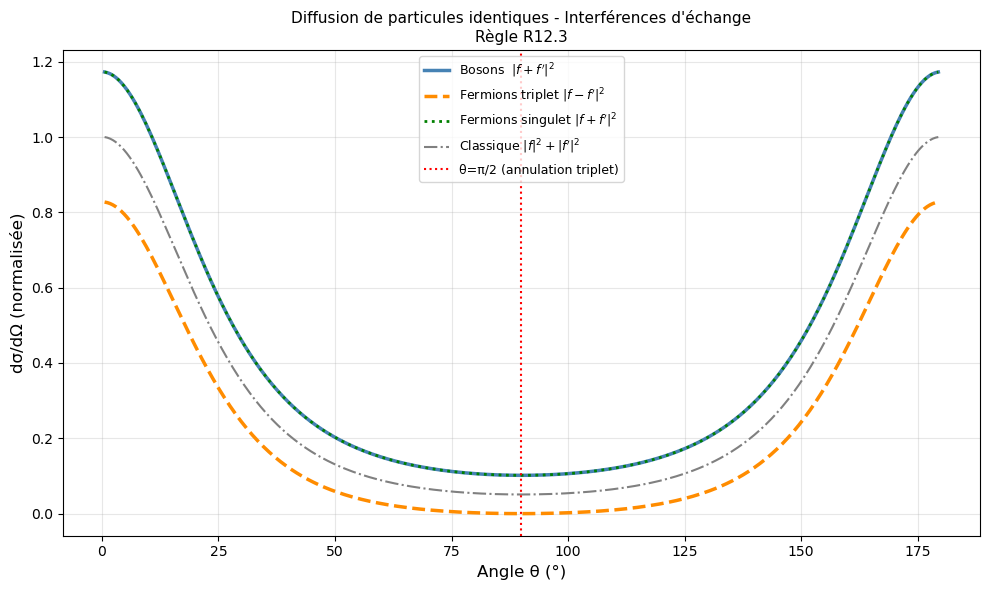

Figure sauvegardée → results/08_identical_scattering.png


In [9]:
# Amplitude de diffusion de Born : f(θ) pour le potentiel de Yukawa
f_forward  = born.scattering_amplitude(theta_grid, r_max=r_max)
f_exchange = np.array([born.scattering_amplitude(np.array([np.pi - t]), r_max=r_max)[0]
                       for t in theta_grid])

sigma_boson   = IdenticalParticlesScattering.cross_section_bosons(f_forward, f_exchange, theta_grid)
sigma_singlet = IdenticalParticlesScattering.cross_section_fermions_singlet(f_forward, f_exchange, theta_grid)
sigma_triplet = IdenticalParticlesScattering.cross_section_fermions_triplet(f_forward, f_exchange, theta_grid)
sigma_classic = IdenticalParticlesScattering.cross_section_classical(f_forward, f_exchange, theta_grid)

# Annulation à θ=π/2 pour fermions triplet
i_half = np.argmin(np.abs(theta_grid - np.pi/2))
print(f'Vérification σ_triplet(π/2) = {sigma_triplet[i_half]:.4e}  (attendu : 0)')
ok_zero = symv.fermion_triplet_zero_at_pi_half(sigma_triplet, theta_grid)
print(f"  {'✓' if ok_zero['is_zero'] else '✗'} σ_triplet(π/2) = 0  (|f-f'| = 0 par symétrie)")

fig, ax = plt.subplots(figsize=(10, 6))
theta_deg = np.degrees(theta_grid)
ref = sigma_classic / sigma_classic.max()
ax.plot(theta_deg, sigma_boson  / sigma_classic.max(), 'steelblue', lw=2.5, label="Bosons  $|f+f'|^2$")
ax.plot(theta_deg, sigma_triplet/ sigma_classic.max(), 'darkorange', lw=2.5, ls='--',
        label="Fermions triplet $|f-f'|^2$")
ax.plot(theta_deg, sigma_singlet/ sigma_classic.max(), 'green', lw=2, ls=':',
        label="Fermions singulet $|f+f'|^2$")
ax.plot(theta_deg, ref,          'gray',  lw=1.5, ls='-.', label="Classique $|f|^2+|f'|^2$")
ax.axvline(90, color='red', ls=':', lw=1.5, label='θ=π/2 (annulation triplet)')
ax.set_xlabel('Angle θ (°)', fontsize=12)
ax.set_ylabel('dσ/dΩ (normalisée)', fontsize=12)
ax.set_title("Diffusion de particules identiques - Interférences d'échange\nRègle R12.3",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/08_identical_scattering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/08_identical_scattering.png')


## 6. Validation finale — résumé

In [10]:
print('BILAN DE VALIDATION — Tome 2 Ch. VIII et XIV')
print('=' * 60)

# Diffusion
print()
print('  DIFFUSION :')
ok_born_nonneg = ok_diff_pos
ok_born_regime = born_regime['is_valid']
print(f"    {'✓' if ok_born_nonneg else '✗'} dσ/dΩ ≥ 0 partout")
print(f"    (i) Théorème optique Born : violation attendue (Im[f_Born]=0)")
print(f"    {'✓' if ot_pw['is_valid']    else '✗'} Théorème optique ondes partielles")
print(f"    {'✓' if ok_unit             else '✗'} Borne d'unitarité |δₗ| < π/2")
print(f"    {'✓' if ok_born_regime else '✗'} Régime Born valide")

# Particules identiques
print()
print('  PARTICULES IDENTIQUES :')
print(f"    {'✓' if res_sym['is_correct']     else '✗'} État bosonique symétrique (+1)")
print(f"    {'✓' if res_antisym['is_correct'] else '✗'} État fermionique antisymétrique (-1)")
print(f"    {'✓' if ok_norm                   else '✗'} Normalisation Slater")
print(f"    {'✓' if ok_pauli                  else '✗'} Pauli  (états orthogonaux)")
print(f"    {'✓' if ok_pauli_id               else '✗'} Pauli  (états identiques → det=0)")
print(f"    {'✓' if ok_zero['is_zero']        else '✗'} σ_triplet(π/2) = 0")

all_checks = [
    ok_born_nonneg, ot_pw['is_valid'], ok_unit,
    ok_born_regime, res_sym['is_correct'], res_antisym['is_correct'],
    ok_norm, ok_pauli, ok_pauli_id, ok_zero['is_zero'],
]
print()
print(f"  {'✓ Toutes les validations réussies !' if all(all_checks) else '✗ Certaines validations ont échoué'}")


BILAN DE VALIDATION — Tome 2 Ch. VIII et XIV

  DIFFUSION :
    ✓ dσ/dΩ ≥ 0 partout
    (i) Théorème optique Born : violation attendue (Im[f_Born]=0)
    ✓ Théorème optique ondes partielles
    ✓ Borne d'unitarité |δₗ| < π/2
    ✓ Régime Born valide

  PARTICULES IDENTIQUES :
    ✓ État bosonique symétrique (+1)
    ✓ État fermionique antisymétrique (-1)
    ✓ Normalisation Slater
    ✓ Pauli  (états orthogonaux)
    ✓ Pauli  (états identiques → det=0)
    ✓ σ_triplet(π/2) = 0

  ✓ Toutes les validations réussies !
